# Data Preparation

## Import Libraries

In [253]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from math import ceil
import math
from difflib import SequenceMatcher

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler

from sklearn.impute import KNNImputer


## Create Meta Data

**carID:** An atribute that contains an identifier for each car.

**Brand:** The cars main brand (e.g., Ford, Toyota).

**model:** The car model.

**year:** The year of registration of the car.

**price:** The car's price when purchased by Cars 4 You (in £).

**transmission:** The car's type of transmission.

**mileage:** The total reported distance travelled by the car (in miles).

**tax:** The amount of road tax (in £) that, in 2020, was applicable to the car in question.

**fuelType:** Type of Fuel used by car (Diesel, Petrol, Hybrid, Electric).

**mpg:** Average Miles per Gallon.

**engineSize:** Size of Engine in liters (Cubic Decimeters).

**paintQuality%** The mechanic’s assessment of the cars’ overall paint quality and hull integrity (filled by the mechanic during evaluation). 

**previousOwner:** Number of previous registered owners of the vehicle.

**hasDamage:** Boolean marker filled by the seller at the time of registration stating whether the car is damaged or not.

**price:** The car's price when purchased by Cars 4 You (in £).

## Import Dataset

In [254]:
sample = pd.read_csv('../data/sample_submission.csv')
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

### Define new index for our datasets

In [255]:
sample.set_index('carID', inplace = True)
train.set_index('carID', inplace = True)
test.set_index('carID', inplace = True)

## Types correction

In the EDA phase we noticed some inconsistencies in the variables types. We will further decide what to do with this errors and correct them.

Before even start we create a copy of the original dataframes to avoid any unwanted changes to the original data.

In [256]:
train = train.copy()
test = test.copy()

We are going to decide how to correct the data and this decision will be based on the percentage of incorrect values.

We will analyse the train dataset and take action in both train and test datasets.

In [257]:
# year, previousOwners as float
(train['year'] % 1 != 0).value_counts() # the true values are the incorrect ones
(train['previousOwners'] % 1 != 0).value_counts() # the true values are the incorrect ones

#percentage of incorrect values as float
num_incorrect_year = (train['year'] % 1 != 0).sum() / train.shape[0] * 100
print(f'Percentage of incorrect values in year column: {num_incorrect_year:.2f}%')
num_incorrect_previousOwners = (train['previousOwners'] % 1 != 0).sum() / train.shape[0] * 100
print(f'Percentage of incorrect values in previousOwners column: {num_incorrect_previousOwners:.2f}%')



Percentage of incorrect values in year column: 2.91%
Percentage of incorrect values in previousOwners column: 3.01%


We decide to round all values of the features even if the percentage of incorrect close to 3%.

In [258]:
def correct_float_columns(df, columns):
    for col in columns:
        df[col] = df[col].round().astype('Int64') #'Int64' is used to keep missing values and still use the round and asType
    return df

train = correct_float_columns(train, ['year', 'previousOwners', 'hasDamage'])
test = correct_float_columns(test, ['year', 'previousOwners', 'hasDamage'])

## Numeric Features Treatment

We already notice that we have some negative values on the feature mileage, tax, mpg, engineSize and previousOwner that make no sense.

What should we do with this negative values? First of all we'll analyse their percentage:

In [259]:
mileage_train_negatives = train['mileage']<0
tax_train_negatives = train['tax']<0
mpg_train_negatives = train['mpg']<0
engineSize_train_negatives = train['engineSize']<0
previousOwners_train_negatives = train['previousOwners']<0


#here we used chatGPT to help us to construct the following DataFrame
negatives_summary = pd.DataFrame({
    'mileage_negatives': mileage_train_negatives.value_counts(),
    'tax_negatives': tax_train_negatives.value_counts(),
    'mpg_negatives': mpg_train_negatives.value_counts(),
    'engineSize_negatives': engineSize_train_negatives.value_counts(),
    'previousOwners_negatives': previousOwners_train_negatives.value_counts()
})

negatives_summary

,mileage_negatives,tax_negatives,mpg_negatives,engineSize_negatives,previousOwners_negatives
False,75604,75595,75937,75889,74052
True,369,378,36,84,371


In [260]:
#Check the percentage of negative mileage values
data_len = len(train['mileage'])

#Here we used chatGPT to help us constructing the final negatives_table
negatives_percent = {
    'mileage_negatives (%)': mileage_train_negatives.sum() / data_len * 100,
    'tax_negatives (%)': tax_train_negatives.sum() / data_len * 100,
    'mpg_negatives (%)': mpg_train_negatives.sum() / data_len * 100,
    'engineSize_negatives (%)': engineSize_train_negatives.sum() / data_len * 100,
    'previousOwners_negatives (%)': previousOwners_train_negatives.sum() / data_len * 100
}

# Converter para DataFrame (tabela)
negatives_table = pd.DataFrame(negatives_percent, index=['Percentage of Negatives']).round(3)

negatives_table

,mileage_negatives (%),tax_negatives (%),mpg_negatives (%),engineSize_negatives (%),previousOwners_negatives (%)
Percentage of Negatives,0.486,0.498,0.047,0.111,0.488


From the negatives_table we obtain very low percentages for each variable, lower than 1%. So it's possible to conclude that this values are a small part of our data and that if we drop them we don't loose veracity.

We can also see that the total percentage of negative values is lower then 2%.

The first two approaches that came in our minds where drop this negative values or turn them into their absolute value.

We decide to take the 2nd approach.

In [261]:
def correct_negative_values(df, columns):
    for col in columns:
        df[col] = df[col].abs()
    return df

train = correct_negative_values(train, ['mileage', 'tax', 'mpg', 'engineSize', 'previousOwners'])
test = correct_negative_values(test, ['mileage', 'tax', 'mpg', 'engineSize', 'previousOwners'])

Th rest of the data still have some incosistencies in features like PaintQuality% that is a percentage and has values greater than 100%. 

To deal with this we start to check the percentage of this errors.

In [262]:
(train['paintQuality%']>100).value_counts() # the true values are the incorrect ones

percentage = (train['paintQuality%']>100).sum() / train.shape[0] * 100
print(f'Percentage of incorrect values in paintQuality% column: {percentage:.2f}%')


Percentage of incorrect values in paintQuality% column: 0.48%


The incorrect values that we found can have different reasons. For example, a typing error which added 1 before the value (25%-125%) or they can represent 100%. As we don't know the real reason and this values represent a small percentage of the all data we decided to drop them and later change the approach if it's needed.

In [263]:
def drop_high_percentages(df, column, max_value):
    df.drop(df[df[column] > max_value].index, inplace=True)
    return df

train = drop_high_percentages(train, 'paintQuality%', 100)
test = drop_high_percentages(test, 'paintQuality%', 100)

In the HasDamage column, we have 0's and NaN and we decided to fill the NaN's with 1's to create a boolean variable which will be easier for next analysis. We agree that this change was urgent and because of that was done before the splitting.

In [264]:
train['hasDamage']=train['hasDamage'].fillna(1)
test['hasDamage']=test['hasDamage'].fillna(1)

TO DO:
- corrigir types
- remover outliers graves, que são erros e visualizar boxplots
- Feature engineering: Criar features que não envolvem cálculos c/ média, mediana, …
Fazer tudo isto para o training and test set

## Categorical Features Treatment

### Creating the Correction Function

We start to create a function that correct this strange values by using the library difflib.

In [265]:
from difflib import SequenceMatcher

def similar(a, b):
    return SequenceMatcher(None, a, b).ratio()

def clean_with_diff(
    df, column,
    threshold_short=0.75,
    threshold_long=0.85
    
):
    """
    Groups similar values and replaces them by the most frequent (mode).
    threshold_short: similarity threshold when both strings have <= 5 chars
    threshold_long: similarity threshold otherwise
    min_shared_chars: minimum number of characters in common to merge short strings
    """
    
    values = df[column].dropna().unique()
    groups = []
    used = set()
    # min_shared_chars= [3 if X2[X2['brand'].isin(["bmw", "audi"]) else 2 for brand in X2['brand']]
    
    for v in values:
        if v in used:
            continue
        
        group = [v]
        used.add(v)
        
        for other in values:
            if other in used:
                continue

            # Choose the threshold
            if len(v) <= 5 and len(other) <= 5:
                threshold = threshold_short
                # Check min shared characters
                # shared_chars = len(set(v.lower()) & set(other.lower()))
                # if shared_chars < min_shared_chars:
                    # continue
            else:
                threshold = threshold_long

            # Check similarity
            if similar(v.lower(), other.lower()) >= threshold:
                group.append(other)
                used.add(other)
        
        groups.append(group)
    
    # Create mapping for each group
    mapping = {}
    for group in groups:
        moda = df[df[column].isin(group)][column].mode()[0]
        for item in group:
            mapping[item] = moda
    
    df[column] = df[column].map(mapping).fillna(df[column])
    
    return df


### Correct the values

Now we are able to correct the values:

In [266]:
# Correct 'Brand' column
clean_with_diff(train, 'Brand', threshold_short=0.6, threshold_long=0.6)
clean_with_diff(test, 'Brand', threshold_short=0.5, threshold_long=0.6)

# Correct 'transmission' column
clean_with_diff(train, 'transmission', threshold_short=0.7, threshold_long=0.7)
clean_with_diff(test, 'transmission', threshold_short=0.7, threshold_long=0.7)

# Correct 'model' column
clean_with_diff(train, 'model', threshold_short=0.70, threshold_long=0.90)
clean_with_diff(test, 'model', threshold_short=0.70, threshold_long=0.90)

# Correct 'fuelType' column
clean_with_diff(train, 'fuelType', threshold_short=0.8, threshold_long=0.8)
clean_with_diff(test, 'fuelType', threshold_short=0.8, threshold_long=0.8)

# The output show us a part of the dataframe after the values corrections

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,
89856,Hyundai,I10,2023,Automatic,30700.000000,Petrol,205.0,41.5,1.6,61.0,3,0
106581,VW,Tiguan,2017,Semi-Auto,48190.655673,Petrol,150.0,38.2,2.0,60.0,2,0
80886,BMW,2 Series,2016,Automatic,36792.000000,Petrol,125.0,51.4,1.5,94.0,2,0
100174,Opel,Grandland X,2019,Manual,5533.000000,Petrol,145.0,44.1,1.2,77.0,1,0
81376,BMW,1 Series,2019,Semi-Auto,9058.000000,Diesel,150.0,51.4,2.0,45.0,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...
105775,VW,Tiguan,2017,Manual,27575.000000,Petrol,145.0,46.3,1.4,94.0,1,0
81363,BMW,X2,2020,Automatic,1980.000000,Petrol,145.0,34.0,2.0,39.0,3,0
76833,Audi,Q5,2019,Semi-Auto,8297.000000,Diesel,145.0,38.2,2.0,88.0,4,0


### Check corrections

In [267]:
corrected_columns = ['Brand', 'transmission', 'model', 'fuelType']

for column in corrected_columns:
    unique_values_train = train[column].unique()
    unique_values_test = test[column].unique()
    print(f"Unique values on the column '{column}' (train): {unique_values_train}")
    print('')
    print(f"Unique values on the column '{column}' (test): {unique_values_test}")
    print('')
    print('-----------------------------------')
    print('')

Unique values on the column 'Brand' (train): ['VW' 'Toyota' 'Audi' 'Ford' 'BMW' 'Skoda' 'Opel' 'Mercedes' 'Hyundai' nan]

Unique values on the column 'Brand' (test): ['Hyundai' 'VW' 'BMW' 'Opel' 'Ford' 'Mercedes' 'Skoda' 'Toyota' 'Audi' nan]

-----------------------------------

Unique values on the column 'transmission' (train): ['Semi-Auto' 'Manual' 'Automatic' nan 'unknown' 'Other']

Unique values on the column 'transmission' (test): ['Automatic' 'Semi-Auto' 'Manual' 'unknown' nan 'Other']

-----------------------------------

Unique values on the column 'model' (train): [' Golf' ' Yaris' ' Q2' ' Fiesta' ' 2 Series' ' 3 Series' ' A3' ' Octavia'
 ' Passat' ' Focus' ' Insignia' ' A Class' ' Q3' ' Fabia' ' Ka+'
 ' GLC Class' ' I10' ' C Class' ' Polo' ' E Class' ' Q5' ' Up' ' C-HR'
 ' Mokka X' ' Corsa' ' Astra' ' TT' ' 5 Series' ' Aygo' ' 4 Series' ' SLK'
 ' Viva' ' T-Roc' ' EcoSport' ' Tucson' nan ' X-CLASS' ' X2' ' Rapid'
 ' A1' ' Auris' ' Sharan' ' Adam' ' X3' ' A8' ' B-MAX' ' A4' ' 

**Important Note:** For most of the columns that were corrected, the function seems to have worked properly.
However, in the case of the 'model' column, the results were not as good as in the other columns. This is because the original data contained many unique and incorrect values, some of which were very similar to each other, making it impossible to achieve a perfect correction.

Nevertheless, the vast majority of the data is now properly cleaned and corrected.

Also based on the previous unique values analysis, we decided to check the percentage of the 'Other' category in the 'transmission' column. If the proportion is not significant, we believe it would be reasonable to replace it with an 'Unknown' category, as this simplification could make the next steps of our analysis easier and more consistent.

In [268]:
(train[train['transmission'] == 'Other'].shape[0] / train.shape[0] * 100).__round__(4)

0.0066

The percentage is completly irrelevant so we are going to replace the category as mencioned before.

In [269]:
#Replace 'Other' to 'Unkown'
train['transmission'] = train['transmission'].replace('Other', 'unknown')
test['transmission'] = test['transmission'].replace('Other', 'unknown')
print(train['transmission'].unique())
print(test['transmission'].unique())

['Semi-Auto' 'Manual' 'Automatic' nan 'unknown']
['Automatic' 'Semi-Auto' 'Manual' 'unknown' nan]


## Define the independent variables as X and the dependent as Y

In [270]:
X = train.drop('price', axis = 1)
y = train['price']

## Feature Engineering before split

On this step of the project we create new variables that make sense and can help us predicting our target. For now the variables that we want to add are:
 - `car_age:` calculate the age of the car considering the current year and the year of his registration. This feature help us to capture depreciation, this is, older cars tend to be cheaper.
- `is_recent_model:` binary flag, 1 if the car is less than 3 years old, otherwise 0. We decided to create this feature because highlights newer cars, usually have higher resale prices.

- `mileage_category:` transforms the original continuous mileage feature into an ordered categorical variable with five usage levels according to the total number of mileage they have traveled.  tThis way it's easier to capture differences in vehicle wear and market value.

- `is_hybrid_or_eletric:` binary indicator that is 1 if the fuel type is Hybrid or Electric. Eco-friendly cars often hold higher market value.

- `is_automatic:`binary indicator that is 1 if the type of transmission is automatic or semi-automatic. Automatics typically cost more to buy and maintain.

- `fuel_eficciency_score:` Ratio of mpg / engineSize. Captures how efficiently the car converts fuel given engine capacity.

- `tax_to_engine_ratio:` Tax value divided by engine size. Indicates how expensive it is to maintain the car relative to its power.

- `tax_efficency:` mpg / tax. Measures how fuel-efficient the car is relative to its yearly tax burden.

- `paint_quality_category:` Paint quality binned into Low, Medium, High.

- `has_damage_or_low_paint:` Binary flag, 1 if the car is damaged or has low paint quality (<40%). Combines visible and declared damage into a single condition indicator.

- `is_first_owner:` binary indicator that is 1 if there were no previous owners. First-owner cars tend to have less wear, better care and higher prices.

- `ownership_ratio:` previousOwner / car_age. Captures how frequently ownership changed. Frequent changes might signal reliability issues.

To do this we'll implement some functions that help us defining this new variables.

In [271]:
def car_age_features(X, current_year=2020, threshold=3): 
    """Calculate car age from the registration year and marks whether the car is considered recent."""
    X["car_age"] = current_year - X["year"]
    X["is_recent_car"] = (X["car_age"] <= threshold).astype('Int64')
    return X

def mileage_category(X):
    """Creates a simple categorical feature 'mileage_category' based on the total mileage of each car."""
    bins = [0, 10_000, 50_000, 100_000, 150_000, float('inf')]
    labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']

    X['mileage_category'] = pd.cut(X['mileage'], bins=bins, labels=labels, include_lowest=True)
    return X

def fuel_transmission_features(X):
    """Binary flags for eco-friendly and automatic cars."""
    X["is_hybrid_or_electric"] = X["fuelType"].isin(["Hybrid", "Electric"]).astype(int)
    X["is_automatic"] = X["transmission"].isin(["Automatic", "Semi-Auto"]).astype(int)
    X["fuel_efficiency_score"] = X["mpg"] / X["engineSize"]
    return X


def tax_and_efficiency_features(X):
    """Economic indicators based on tax and engine size."""
    X["tax_to_engine_ratio"] = X["tax"] / X["engineSize"]
    X["tax_efficiency"] = X["mpg"] / X["tax"]
    return X

def condition_features(X):
    """Simplify paint quality and damage info."""
    X["paintQuality_category"] = pd.cut(X["paintQuality%"],
                                         bins=[0, 40, 70, 100],
                                         labels=["Low", "Medium", "High"])
    X["has_damage_or_low_paint"] = ((X["hasDamage"] == 1) | (X["paintQuality%"] < 40)).astype(int)
    return X

def ownership_features(X):
    """Ownership-related flags."""
    X["is_first_owner"] = (X["previousOwners"] == 0).round().astype('Int64')
    X["ownership_ratio"] = np.where(X["car_age"] > 0, X["previousOwners"] / X["car_age"], 0)
                                     
    return X


# Apply all feature functions
X_fe = X.copy()

X_fe = (X_fe
        .pipe(car_age_features)
        .pipe(mileage_category)
        .pipe(fuel_transmission_features)
        .pipe(tax_and_efficiency_features)
        .pipe(condition_features)
        .pipe(ownership_features)
       )

# Inspect results
print("New columns created:")
print([col for col in X_fe.columns if col not in X.columns])



print('--------------------------------------------------------------------')
print('Now we visualize the dataframe with the new features created to understand them better:')

novas_features = [col for col in X_fe.columns if col not in X.columns]
X_fe[novas_features].head(10)

TypeError: boolean value of NA is ambiguous

In [ ]:
X = X_fe.copy()  # Update X to include new features

## Split the dataset into train and validation

In [272]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X,y, test_size = 0.3, 
                                                  random_state = 0, 
                                                  shuffle = True)

## Feature Engineering after split

On this step of the project we create new variables that make sense and can help us predicting our target. To create this new features we need to do some calculations like median and average. Because of this we are creating them after the train-validation split.

For now the variables that we want to add are:

- `brand_median_mileage:` mileage median per brand. Typical mileage level for each brand that is able to capture brand usage patterns.

- `brand_avg_engineSize`: engineSize mean per brand. Represents typical engine capacity of each brand.

- `model_median_tax:` median tax per model. Captures model-specific taxation tendencies.

- `fueltype_avg_mpg:` mpg mean peruelType. Average fuel efficiency for each fuel type.

- `brand_avg_age:` car_age mean er brand. Average car age per brand, basically compare newer against older brands.

To do this we'll implement some functions that help us defining this new variables.

In [ ]:
def brand_median_mileage(df):
    df['brand_median_mileage'] = df['Brand'].map(df.groupby('Brand')['mileage'].median())
    return df

def brand_avg_engineSize(df):
    df['brand_avg_engineSize'] = df['Brand'].map(df.groupby('Brand')['engineSize'].mean())
    return df

def model_median_tax(df):
    df['model_median_tax'] = df['model'].map(df.groupby('model')['tax'].median())
    return df

def fueltype_avg_mpg(df):
    df['fueltype_avg_mpg'] = df['fuelType'].map(df.groupby('fuelType')['mpg'].mean())
    return df

def brand_avg_age(df, reference_year=2025):
    df['brand_avg_age'] = df['Brand'].map((df['car_age'] - df['year']).groupby(df['Brand']).transform('mean'))
    return df


X_train_fe = X_train.copy()
X_train_fe = (X_train_fe
           .pipe(brand_median_mileage)
           .pipe(brand_avg_engineSize)
           .pipe(model_median_tax)
           .pipe(fueltype_avg_mpg)
           .pipe(brand_avg_age))


# Inspect results
print("New columns created:")
print([col for col in X_train_fe.columns if col not in X_train.columns])



print('--------------------------------------------------------------------')
print('Now we visualize the dataframe with the new features created to understand them better:')

novas_features = [col for col in X_train_fe.columns if col not in X_train.columns]
X_train_fe[novas_features].head(10)

KeyError: 'car_age'

## Splitting datasets into Numeric and Categorical Features

We strat by splitting our features in numeric and non_numeric.

In [273]:
# For training set
X_num_train = X_train[['year', 'mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners']]
X_cat_train = X_train.drop(columns=X_num_train.columns)

# For validation set
X_num_val = X_val[['year', 'mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners']]
X_cat_val = X_val.drop(columns=X_num_val.columns)

# For test set
X_num_test = test[['year', 'mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners']]
X_cat_test = test.drop(columns=X_num_test.columns)

In [274]:
print("Numeric Features:")
for i, feature in enumerate(X_num_train, 1):
    print(f" {i}. {feature}")

print("\nCategorical Features:") #hasDamage is a binary feature that we can treat as categorical
for i, feature in enumerate(X_cat_train, 1):
    print(f" {i}. {feature}")

Numeric Features:
 1. year
 2. mileage
 3. tax
 4. mpg
 5. engineSize
 6. paintQuality%
 7. previousOwners

Categorical Features:
 1. Brand
 2. model
 3. transmission
 4. fuelType
 5. hasDamage


## Outliers

Outliers are extreme values that differ significantly from the majority of the data. Their presence can distort statistical analyses and affect the performance of machine learning models. To identify them, we decided to use the Interquartile Range (IQR) method and apply it to all numerical variables. This approach considers values below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR as potential outliers. The following analysis identifies the number and percentage of outliers per variable, helping to evaluate whether data cleaning or transformation might be necessary before modeling.

### Outliers Analysis

In [275]:
def outlier_summary(df):
    """Generates a summary table of outliers for each numeric column using IQR method."""
    numeric_cols = df.columns.tolist()

    summary = []

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Boolean mask for outliers
        outliers = (df[col] < lower_bound) | (df[col] > upper_bound)

        total_outliers = outliers.sum()
        pct_outliers = 100 * total_outliers / len(df)

        summary.append({
            "Column": col,
            "Total Outliers": total_outliers,
            "Percentage (%)": round(pct_outliers, 2)
        })

    return pd.DataFrame(summary)

outlier_summary(X_num_train)

,Column,Total Outliers,Percentage (%)
0,year,1241,2.34
1,mileage,2181,4.12
2,tax,14087,26.62
3,mpg,800,1.51
4,engineSize,451,0.85
5,paintQuality%,0,0.00
6,previousOwners,0,0.00


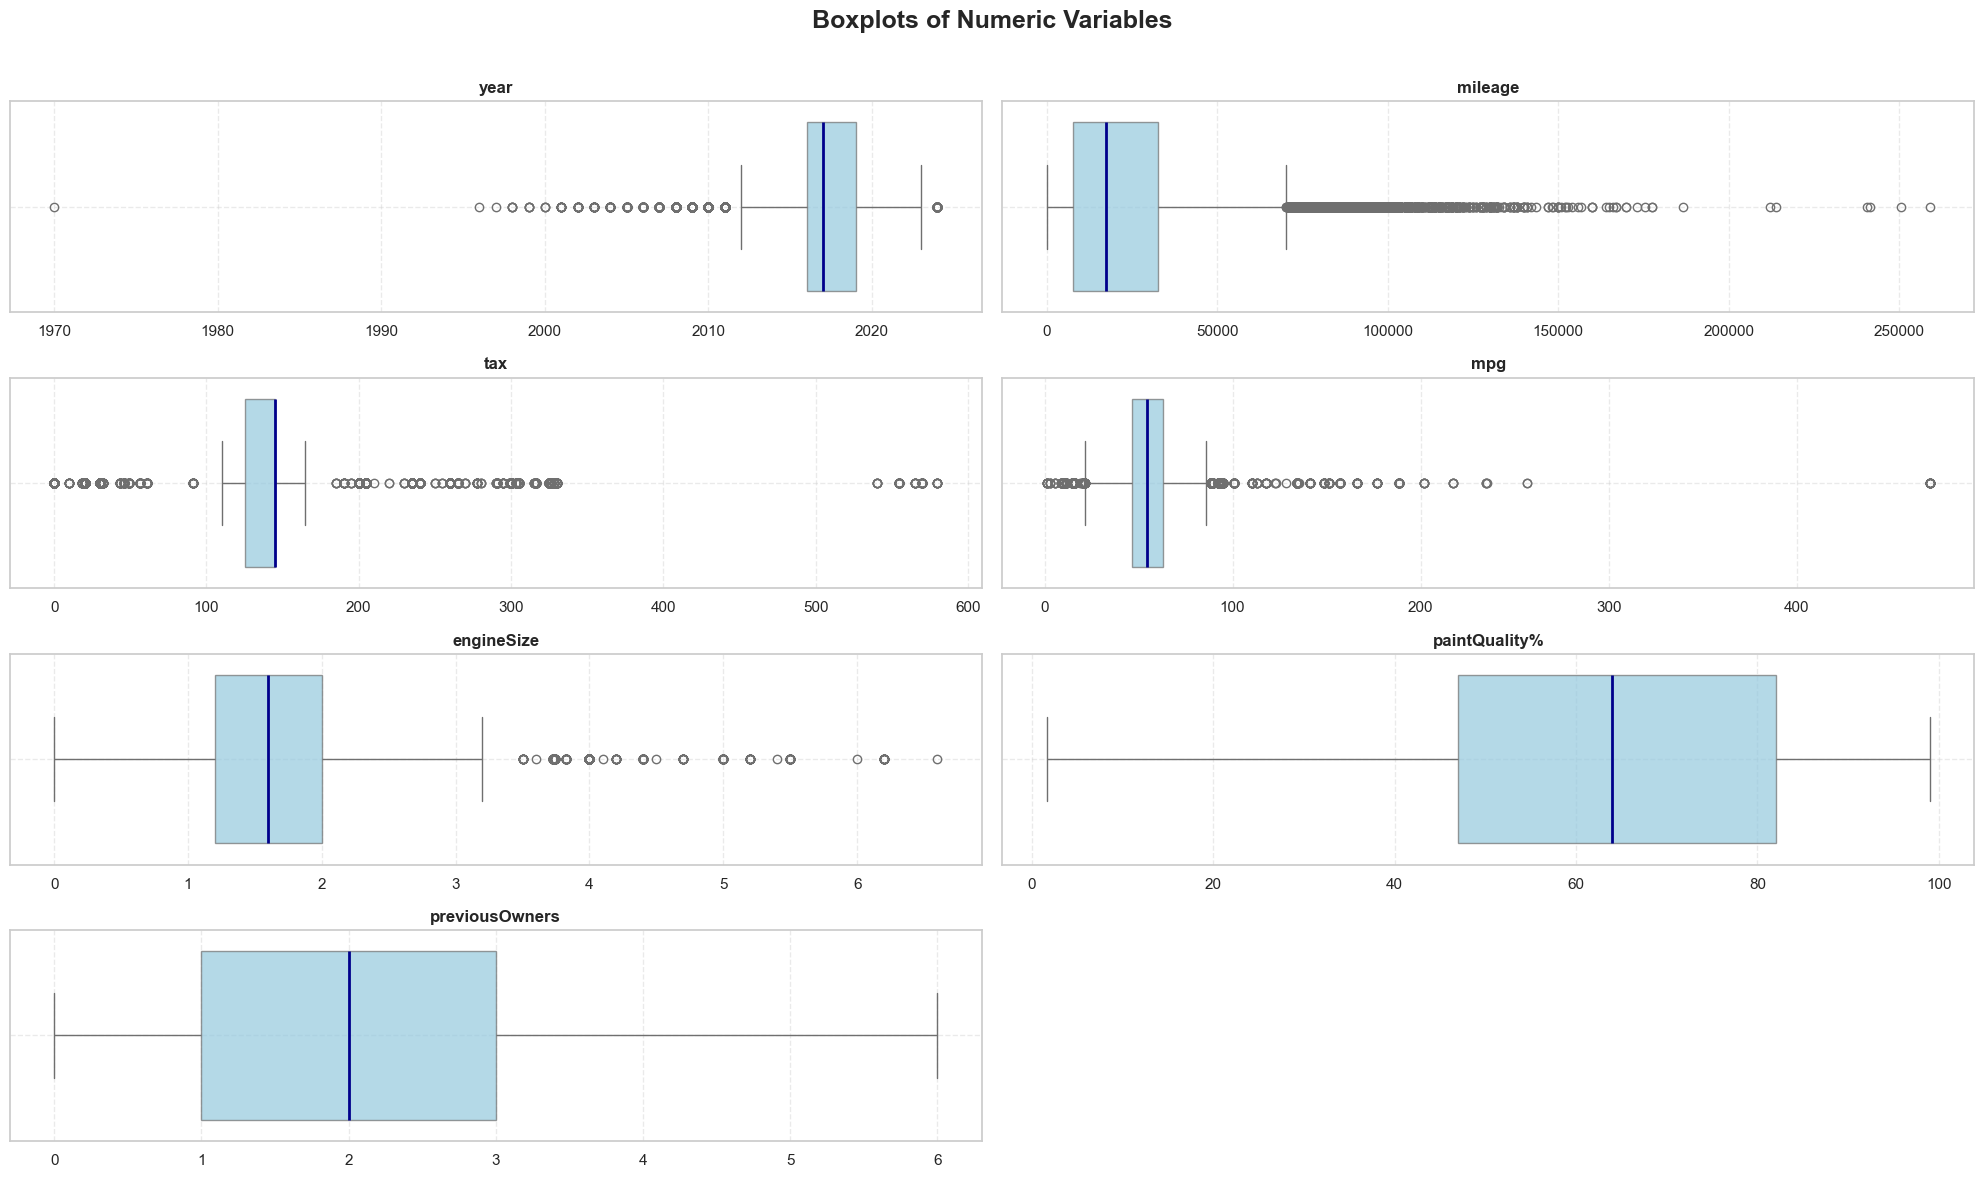

In [276]:
# Style settings
sns.set_theme(style="whitegrid", palette="pastel")

# Prepare figure with appropriate number of rows and columns
n_features = len(X_num_train.columns)
n_cols = 2  
n_rows = ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
axes = axes.flatten()

# Plot boxplots
for i, feat in enumerate(X_num_train.columns):
    ax = axes[i]

    # Boxplot with highlighted median line
    sns.boxplot(
        x=X_num_train[feat],
        ax=ax,
        color='skyblue',
        medianprops={"color": "darkblue", "linewidth": 2},
        boxprops={"alpha": 0.7}
    )
    
    ax.set_title(f"{feat}", fontsize=12, fontweight='bold')
    ax.set_xlabel("")  # Remove automatic x-label
    ax.grid(True, linestyle="--", alpha=0.4)

# Remove empty axes (if the number of features is not a multiple of n_cols)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# General title and layout
plt.suptitle("Boxplots of Numeric Variables", fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### Outliers Treatment

We start by creating a function that treat outliers by capping them to the lower and upper bounds.

After that we apply the function to the numerical datasets and finally have the outliers treatment done.

In [277]:
# df is the reference dataframe to calculate bounds
# df_to_apply is the dataframe where we want to cap the outliers
def treat_outliers(df, df_to_apply, year_col='year'): 
    # Calculate Q1, Q3, and IQR on the reference dataframe
    q1 = df.quantile(0.25)
    q3 = df.quantile(0.75)
    iqr = q3 - q1

    # Define lower and upper bounds
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Round bounds only for the year column
    if year_col in df.columns:
        lower_bound[year_col] = int(np.floor(lower_bound[year_col])) # Use floor to have an integer number in lower bound because we are dealing with years
        upper_bound[year_col] = int(np.ceil(upper_bound[year_col])) # Use ceil to have an integer number in upper bound because we are dealing with years

    # Cap the outliers in the dataframe to apply
    df_capped = df_to_apply.copy()
    for col in df_capped.columns:
        df_capped[col] = df_capped[col].clip(lower=lower_bound[col], upper=upper_bound[col])
    
    return df_capped

In [278]:
X_num_train = treat_outliers(X_num_train, X_num_train)
X_num_val = treat_outliers(X_num_train, X_num_val)
X_num_test = treat_outliers(X_num_train, X_num_test)

Visualize boxplots one more time

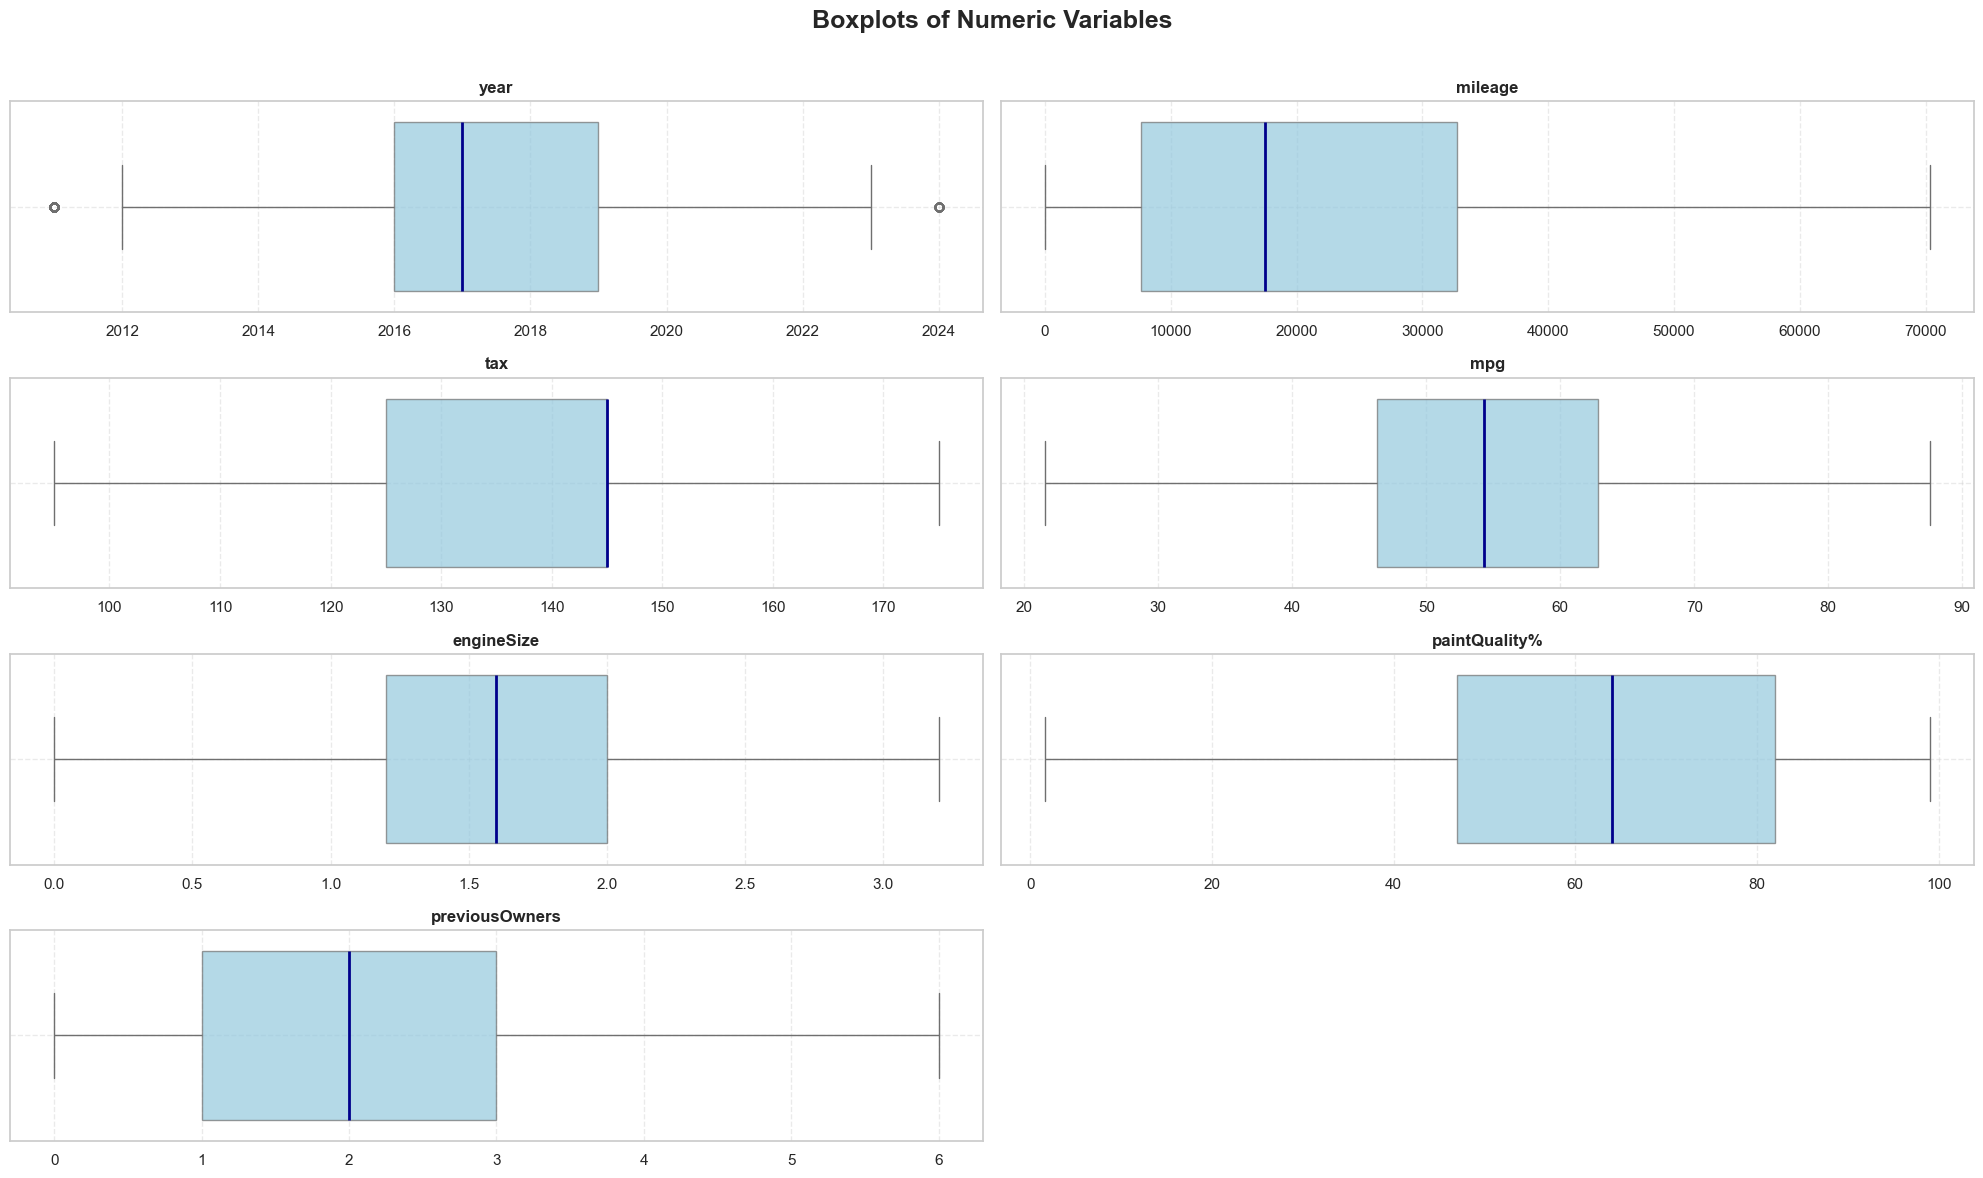

In [279]:
# Style settings
sns.set_theme(style="whitegrid", palette="pastel")

# Prepare figure with appropriate number of rows and columns
n_features = len(X_num_train.columns)
n_cols = 2  
n_rows = ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
axes = axes.flatten()

# Plot boxplots
for i, feat in enumerate(X_num_train.columns):
    ax = axes[i]

    # Boxplot with highlighted median line
    sns.boxplot(
        x=X_num_train[feat],
        ax=ax,
        color='skyblue',
        medianprops={"color": "darkblue", "linewidth": 2},
        boxprops={"alpha": 0.7}
    )
    
    ax.set_title(f"{feat}", fontsize=12, fontweight='bold')
    ax.set_xlabel("")  # Remove automatic x-label
    ax.grid(True, linestyle="--", alpha=0.4)

# Remove empty axes (if the number of features is not a multiple of n_cols)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# General title and layout
plt.suptitle("Boxplots of Numeric Variables", fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


## Missing Values

### Missing Values Analysis

Before starting to fill this missing values, it is important to analyze the amount of missing values in each feature.
Calculating the percentage of missing values helps identify columns with many absent entries and, consequently, decide whether they are relevant for the model or should be discarded or imputed.

In [280]:
# Number of rows in the dataset
rows_number = X_train.shape[0]

# Number of missing values per column
missing_counts = X_train.isnull().sum()

# Percentage of missing values per column
missing_percentage = (missing_counts / rows_number) * 100

# Show in DataFrame format, sorted from highest to lowest
missing_df = missing_percentage.sort_values(ascending=False).reset_index()
missing_df.columns = ['Feature', 'Missing_Percent']

print(missing_df)

           Feature  Missing_Percent
0              mpg        10.396040
1              tax        10.373366
2            Brand         2.042552
3       engineSize         2.042552
4   previousOwners         2.029325
5    paintQuality%         2.019878
6            model         2.010430
7     transmission         2.006651
8             year         2.002872
9         fuelType         1.946187
10         mileage         1.929181
11       hasDamage         0.000000


Although some features have missing values, none have a sufficiently high percentage to warrant removal. All columns are considered relevant and can be retained for modeling, with missing values handled through imputation where necessary.

Split features in different groups of missing values percentages.

In [281]:
low_missing_values = missing_df[missing_df['Missing_Percent'] <= 5.0]['Feature'].tolist()
high_missing_values = missing_df[missing_df['Missing_Percent'] > 5.0]['Feature'].tolist()
print(low_missing_values)
print(high_missing_values)

['Brand', 'engineSize', 'previousOwners', 'paintQuality%', 'model', 'transmission', 'year', 'fuelType', 'mileage', 'hasDamage']
['mpg', 'tax']


Our approach to filling missing values will take into account the percentage of missing data for each feature and will be as follows:
- Features with a low percentage of missing values (<5%) will be imputed using simple methods such as mean, median, or mode.
- Features with a moderate percentage of missing values (5-20%) will be imputed carefully, possibly using more advanced methods such as KNN (if features have low correlation with the others).

### Treat Numeric Missing Values with the median

First we fill the missing values with the median for the features with low percentage:

In [282]:
for col in X_num_train.columns:
    # Check if the column has low or high missing values
    if col in low_missing_values:    
        median_value = X_num_train[col].median() # calculate median from training set
        X_num_train[col].fillna(median_value, inplace=True)
        X_num_val[col].fillna(median_value, inplace=True)
        X_num_test[col].fillna(median_value, inplace=True)

/var/folders/s9/nfpy2jls4ps2k_p8lpjz6_yr0000gn/T/ipykernel_63349/1271078663.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_num_train[col].fillna(median_value, inplace=True)
/var/folders/s9/nfpy2jls4ps2k_p8lpjz6_yr0000gn/T/ipykernel_63349/1271078663.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values a

For the rest of the numeric features that have missing values we'll use the KNN imputer technique because there's a higher percentage of missing values. To use this technique we need to normalize the numeric values first using the MinMaxScaler function.

We will do this after enconding and sclaing all features.

### Treat Categorical Missing Values with the mode

In [283]:
for col in X_cat_train.columns:
    mode_value = X_cat_train[col].mode()[0]  # Get the most frequent value from training data
    
    # Fill missing values in both training and validation sets using the training mode
    X_cat_train[col].fillna(mode_value, inplace=True)
    X_cat_val[col].fillna(mode_value, inplace=True)

/var/folders/s9/nfpy2jls4ps2k_p8lpjz6_yr0000gn/T/ipykernel_63349/783278479.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_cat_train[col].fillna(mode_value, inplace=True)
/var/folders/s9/nfpy2jls4ps2k_p8lpjz6_yr0000gn/T/ipykernel_63349/783278479.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alway

## Encoding

Before training machine learning models, it is necessary to convert categorical variables into a numerical format, as most algorithms cannot process non-numeric data directly. This step, known as encoding, ensures that the categorical information can be effectively interpreted by the models without losing its meaning.

In this section, we will apply `One-Hot Encoding` to features with a small number of categories (Brand, Transmission, fuelType) and use a `Label (Ordinal) Encoder` for the variable that contains many distinct categories (model). This approach allows us to represent all categorical variables in a consistent and efficient way, preparing the dataset for further preprocessing and model development.

In [ ]:
def fit_transform_ohe(fit_df, transform_df, cols):
    """Fits a One-Hot Encoder on fit_df and transforms transform_df using the same encoder."""

    encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore') 
    #sparse=False to get an array as output and handle_unknown='ignore' to avoid errors with unseen categories or missing values

    # Fit on fit_df and transform transform_df
    encoder.fit(fit_df[cols])
    transformed = encoder.transform(transform_df[cols])

    # Create DataFrame with correct column names
    transformed_df = pd.DataFrame(transformed, columns=encoder.get_feature_names_out(cols), index=transform_df.index)

    # Concatenate with other columns and drop originals
    result_df = pd.concat([transform_df.drop(columns=cols), transformed_df], axis=1)
    
    return result_df

In [285]:
X_cat_train_orig = X_cat_train.copy() #keep a copy of the original training categorical data for fitting the encoder

X_cat_train = fit_transform_ohe(X_cat_train_orig, X_cat_train, ['Brand', 'transmission', 'fuelType'])
X_cat_val = fit_transform_ohe(X_cat_train_orig, X_cat_val, ['Brand', 'transmission', 'fuelType'])
X_cat_test = fit_transform_ohe(X_cat_train_orig, X_cat_test, ['Brand', 'transmission', 'fuelType'])

/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## Scaling Features 

In [ ]:
#call function
scaler = MinMaxScaler()

#fit to training data
scaler.fit(X_num_train) #Fit only on the training data

#transform the data
X_train_num_scaled = scaler.transform(X_num_train) # this will return an array
X_val_num_scaled = scaler.transform(X_num_val) # this will return an array
X_test_num_scaled = scaler.transform(X_num_test) # this will return an array

#show results
X_train_num_scaled

## KNN Imputer

In [ ]:
for col in X_num_train.columns:
    # Check if the column has low or high missing values
    if col in high_missing_values:    
        # Creating a KNNImputer with 4 neighbors
        imputer = KNNImputer(n_neighbors=4)
        
        # Fit on the full numeric training set (all columns at once)
        imputer.fit(X_train_num_scaled)

        # Transform both train and validation
        X_train_num_imputed = imputer.transform(X_train_num_scaled)
        X_val_num_imputed = imputer.transform(X_val_num_scaled)

        # Convert back to DataFrames
        X_train_num_imputed = pd.DataFrame(X_train_num_imputed, columns=X_num_train.columns, index=X_num_train.index)
        X_val_num_imputed = pd.DataFrame(X_val_num_imputed, columns=X_num_val.columns, index=X_num_val.index)